# 02. Stock Data Analysis with yfinance

This notebook downloads and compares historical market data for Samsung Electronics (005930.KS), SK Hynix (000660.KS), and Apple (AAPL). It introduces data acquisition, cleaning, return calculations, volatility, moving averages, and correlation.

> An internet connection is required. Historical performance does not guarantee future returns, and this material is for education rather than investment advice.

## 0. Install the Required Libraries

Run this cell once in a new environment. If imports still fail after installation, restart the Jupyter kernel and continue from the next cell.

In [1]:
%pip install -q yfinance pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries and Define the Tickers

The ticker suffix `.KS` identifies securities listed on the Korea Exchange. Apple trades in the United States under `AAPL`. The same date range is requested for all three companies so that their histories can be aligned.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)

TICKERS = {
    "Samsung Electronics": "005930.KS",
    "SK Hynix": "000660.KS",
    "Apple": "AAPL",
}
START = "2025-01-01"
END = None  # Use None to download through the latest available date

## 2. Download, Select, and Inspect the Data

With `auto_adjust=True`, yfinance adjusts historical prices for corporate actions such as stock splits and dividends. A multi-company download usually creates MultiIndex columns. This notebook selects the adjusted closing prices, renames ticker symbols, removes completely empty dates, and forward-fills isolated gaps caused by different exchange holidays.

In [8]:
raw = yf.download(
    list(TICKERS.values()),
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
    group_by="column",
)

if raw.empty:
    raise RuntimeError("No data was downloaded. Check the internet connection and ticker symbols.")

close = raw["Close"].rename(columns={ticker: name for name, ticker in TICKERS.items()})
close = close.dropna(how="all").ffill()
print("Date range:", close.index.min().date(), "~", close.index.max().date())
display(close.head())
display(close.describe().T.round(2))

Date range: 2025-01-02 ~ 2026-08-13


Ticker,SK Hynix,Samsung Electronics,Apple
Date,,,
2025-01-02,169087.015625,52107.093750,242.093140
2025-01-03,179654.968750,53082.886719,241.606659
2025-01-06,197334.062500,54546.566406,243.234848
2025-01-07,192593.296875,54058.675781,240.464920
2025-01-08,192296.984375,55912.667969,240.951385


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SK Hynix,417.0,734470.32,675159.62,163818.34,218272.41,477695.69,949089.75,2919000.00
Samsung Electronics,417.0,131096.16,88270.67,49765.20,57278.77,95927.64,190993.61,362100.66
Apple,417.0,250.18,35.95,171.37,221.04,252.44,272.68,339.79


## 3. Calculate the Main Performance and Risk Measures

- **Daily return** measures the percentage change from one trading day to the next.
- **Total return** compares the final price with the first valid price in the selected period.
- **Annualized volatility** estimates typical price variability by multiplying daily standard deviation by √252, the approximate number of trading days in a year.
- **Best and worst day** provide a quick view of extreme one-day movements.

In [9]:
daily_returns = close.pct_change().dropna(how="all")
normalized = close.div(close.iloc[0]).mul(100)

summary = pd.DataFrame({
    "Starting Price": close.iloc[0],
    "Ending Price": close.iloc[-1],
    "Total Return (%)": (close.iloc[-1] / close.iloc[0] - 1) * 100,
    "Annualized Volatility (%)": daily_returns.std() * np.sqrt(252) * 100,
    "Best Day (%)": daily_returns.max() * 100,
    "Worst Day (%)": daily_returns.min() * 100,
}).round(2)
display(summary)

,Starting Price,Ending Price,Total Return (%),Annualized Volatility (%),Best Day (%),Worst Day (%)
Ticker,,,,,,
SK Hynix,169087.02,1591000.00,840.94,75.39,29.95,-15.37
Samsung Electronics,52107.09,265250.00,409.05,59.48,26.81,-13.39
Apple,242.09,302.25,24.85,30.22,15.33,-9.25


## Visualization 1. Normalized Cumulative Performance

The stocks trade in different currencies and at very different nominal prices. Direct price comparison would therefore be misleading. Dividing every series by its initial value and multiplying by 100 places all companies at the same starting point.

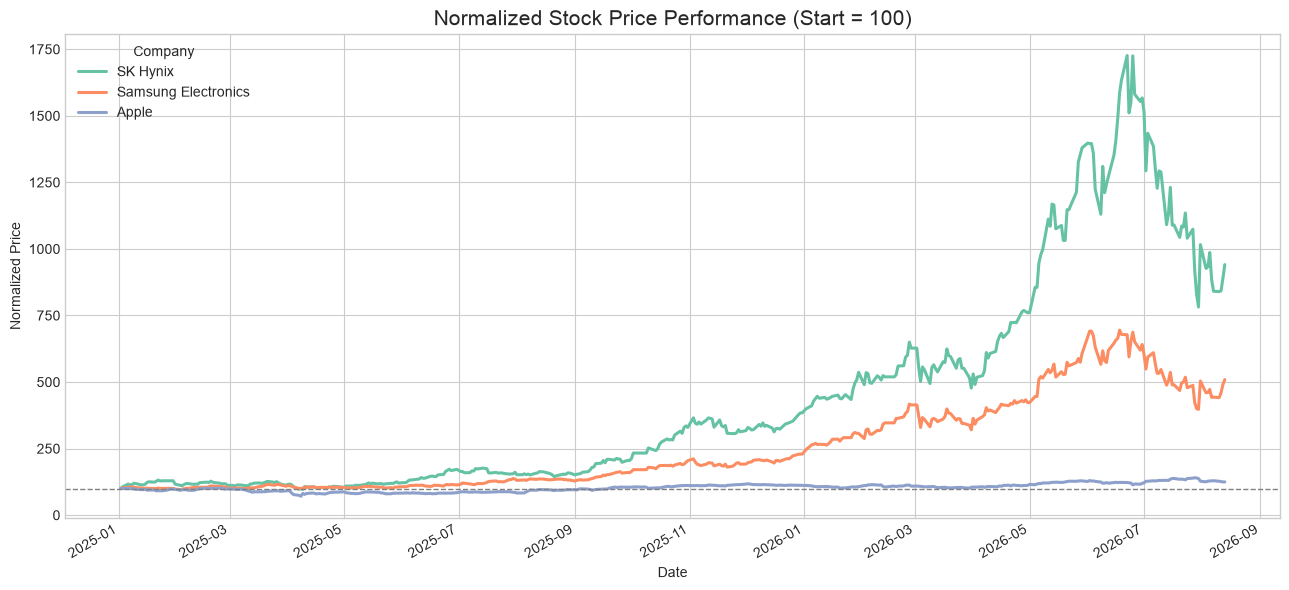

In [12]:
ax = normalized.plot(linewidth=2.2, figsize=(13, 6))
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title("Normalized Stock Price Performance (Start = 100)", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(title="Company")
plt.tight_layout()
plt.show()

### How to Read This Chart

- A value above 100 means the stock is above its starting price; a value below 100 means it is below.
- A value of 135 represents an approximate 35% gain from the first valid observation.
- This is a price-performance comparison. It does not adjust the Korean stocks into US dollars, account for taxes, or represent a complete investment return.

## Visualization 2. Closing Price and 20-Day Moving Average

A moving average smooths short-term fluctuations and makes the underlying direction easier to see. The 20-day window roughly represents one trading month. A closing price above its moving average only means that the latest price is higher than its recent average; it is not, by itself, a reliable buy signal.

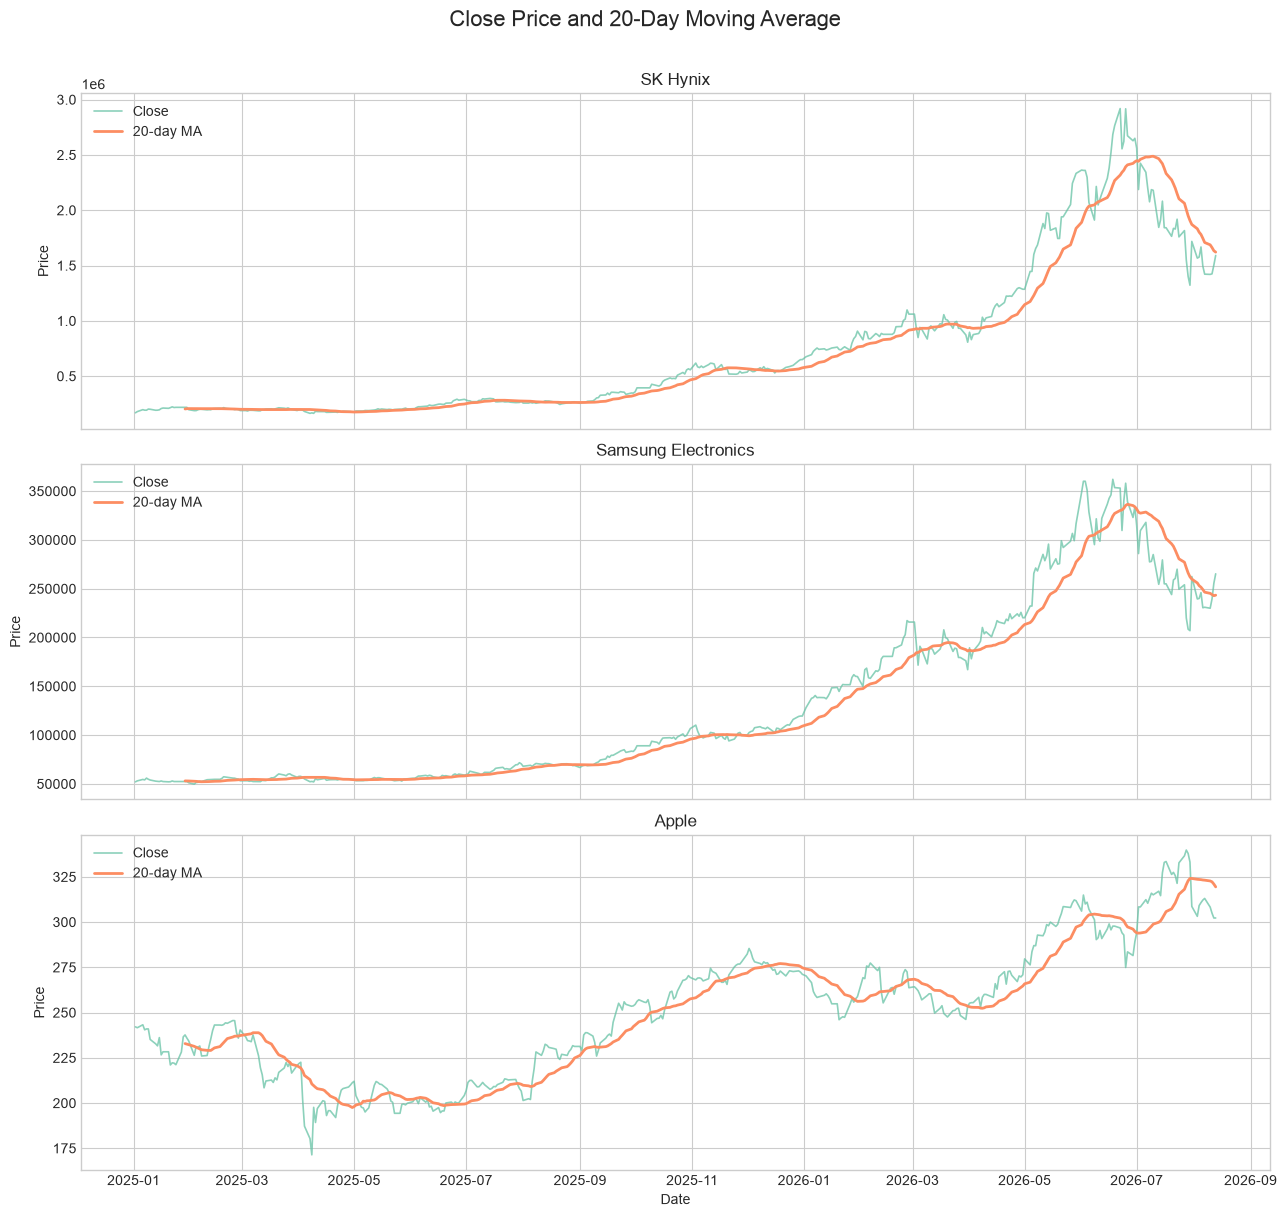

In [13]:
moving_average_20 = close.rolling(window=20).mean()
fig, axes = plt.subplots(len(close.columns), 1, figsize=(13, 12), sharex=True)

for ax, company in zip(axes, close.columns):
    ax.plot(close.index, close[company], label="Close", linewidth=1.2, alpha=0.75)
    ax.plot(moving_average_20.index, moving_average_20[company], label="20-day MA", linewidth=2)
    ax.set_title(company)
    ax.set_ylabel("Price")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Date")
fig.suptitle("Close Price and 20-Day Moving Average", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Interpreting the Summary Table

Total return describes growth over the selected period, while volatility describes the variability of daily returns. A higher return is not automatically better if it was achieved with much greater risk. The best-day and worst-day columns also show why a few unusually large market moves can strongly affect a short sample.

## Visualization 3. Correlation of Daily Returns

Correlation measures the degree to which two return series move together. Values near 1 indicate similar direction, values near -1 indicate opposite direction, and values near 0 indicate little linear relationship. Correlation can change over time and does not establish causation.

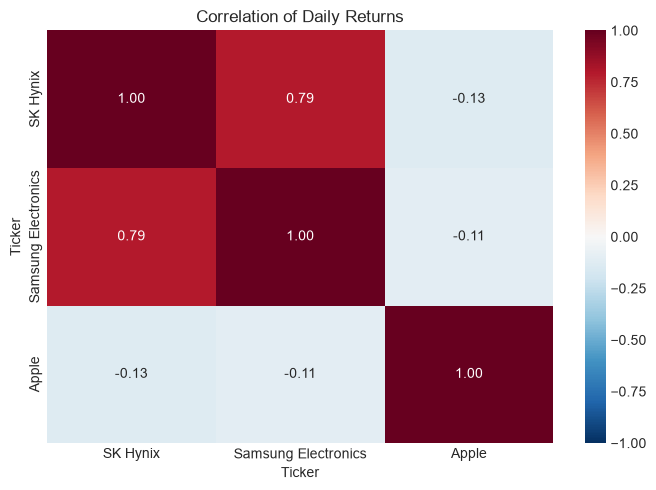

In [14]:
correlation = daily_returns.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation of Daily Returns")
plt.tight_layout()
plt.show()

## Analysis Notes and Limitations

Market datasets require careful interpretation. The three exchanges follow different holiday calendars, and Apple is priced in US dollars while the Korean companies are priced in won. Forward filling aligns dates for comparison but does not create a real trade on a closed market. The results also depend heavily on the chosen start date. For a complete investment analysis, consider exchange rates, dividends, transaction costs, taxes, business fundamentals, and multiple market cycles.